В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [66]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
import os
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from IPython.display import display

In [53]:
import pandas as pd
bank_df = pd.read_csv('train.csv')
bank_df.Exited.value_counts(normalize=True)

Exited
0.0    0.796533
1.0    0.203467
Name: proportion, dtype: float64

In [55]:
train_df, val_df = train_test_split(bank_df, test_size=0.20, random_state=42, stratify=bank_df["Exited"] )
train_df.Exited.value_counts(normalize=True), val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 6490 to 3024
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3000 non-null   int64  
 1   CustomerId       3000 non-null   float64
 2   Surname          3000 non-null   object 
 3   CreditScore      3000 non-null   float64
 4   Geography        3000 non-null   object 
 5   Gender           3000 non-null   object 
 6   Age              3000 non-null   float64
 7   Tenure           3000 non-null   float64
 8   Balance          3000 non-null   float64
 9   NumOfProducts    3000 non-null   float64
 10  HasCrCard        3000 non-null   float64
 11  IsActiveMember   3000 non-null   float64
 12  EstimatedSalary  3000 non-null   float64
 13  Exited           3000 non-null   float64
dtypes: float64(10), int64(1), object(3)
memory usage: 351.6+ KB


(Exited
 0.0    0.7965
 1.0    0.2035
 Name: proportion, dtype: float64,
 None)

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [57]:
input_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
target_col = 'Exited'
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [59]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [64]:
scaler = MinMaxScaler()
scaler.fit(train_inputs[numeric_cols])
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

In [68]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
display(train_inputs.head(5))
display(val_inputs.head(5))

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0,0.0,1.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0,1.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0,0.0,1.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0,0.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0,0.0,1.0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
6490,0.675418,Germany,Male,0.500000,0.1,0.551870,1.000000,1.0,1.0,0.364704,0.0,1.0,0.0,0.0,1.0
3646,0.386635,France,Male,0.410714,0.5,0.000000,0.333333,1.0,1.0,0.190942,1.0,0.0,0.0,0.0,1.0
5306,0.715990,France,Female,0.357143,0.2,0.000000,0.333333,0.0,1.0,0.584853,1.0,0.0,0.0,1.0,0.0
652,0.577566,France,Female,0.446429,0.4,0.742441,0.000000,0.0,1.0,0.558109,1.0,0.0,0.0,1.0,0.0
2627,0.589499,Spain,Female,0.214286,0.4,0.000000,0.333333,1.0,0.0,0.718420,0.0,0.0,1.0,1.0,0.0


Я масштабую числові колонки, тому що буду використовувати градієнтний спуск, а йому так буде легше зійтись.
А також я кодую категоріальні колонки, щоб використати їх для навчання моделі

In [21]:
!pip install pyarrow --quiet

5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [23]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

In [25]:
os.listdir(".")

['.ipynb_checkpoints',
 'application_data.csv.zip',
 'bank_loyalty.joblib',
 'cars.csv',
 'columns_description.csv',
 'HW_1_1_Основи_статистики.ipynb',
 'HW_1_2_Credit_EDA.ipynb',
 'HW_1_2_Credit_EDA_copy.ipynb',
 'HW_2_1_1Тестування_стат_гіпотез.ipynb',
 'HW_2_1_2Аналіз_ознак_для_побудови_лінійної_регресії.ipynb',
 'HW_2_1_3Функції_і_похідні.ipynb',
 'HW_2_1_4Матриці_і_вектори_(вступ_до_лін_алгебри).ipynb',
 'HW_2_1_5Побудова_лінійної_регресії_за_одною_ознакою.ipynb',
 'HW_2_1_6Лінійна_регресія_від_багатьох_змінних.ipynb',
 'HW_2_2_1Математичне_формулювання_логістичної_регресії.ipynb',
 'HW_2_2_2Логістична_регресія_з_scikit_learn.ipynb',
 'HW_2_2_3Поліноміальні_ознаки_Pipelines.ipynb',
 'Kaggle Comp.ipynb',
 'medical-charges.csv',
 'sample_submission.csv',
 'submission_log_reg.csv',
 'submission_log_reg1.csv',
 'test.csv',
 'train.csv',
 'train_inputs.parquet',
 'train_targets.parquet',
 'val_inputs.parquet',
 'val_targets.parquet']

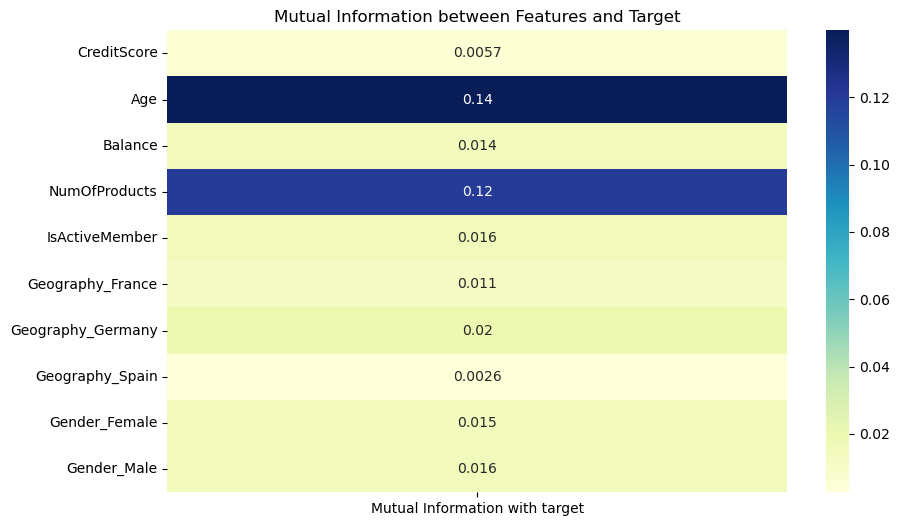

,Mutual Information with target
CreditScore,0.005653
Age,0.139924
Balance,0.014471
NumOfProducts,0.119580
IsActiveMember,0.015923
Geography_France,0.011256
Geography_Germany,0.020114
Geography_Spain,0.002639
Gender_Female,0.014703
Gender_Male,0.016475


In [47]:
from sklearn.feature_selection import mutual_info_classif

feature_cols = train_inputs[numeric_cols + encoded_cols].columns.tolist()

# Считаем взаимную информацию (MI)
mi = mutual_info_classif(train_inputs[numeric_cols + encoded_cols], train_targets, random_state=42) #, discrete_features=feature_cols

# Формируем датафрейм для удобства
mi_df = pd.DataFrame(mi.reshape(1, -1), columns=feature_cols)

# Создадим квадратную матрицу взаимной информации признаков между собой и с целевой (примерно)
# mutual_info_classif — для target, для взаимной информации между признаками можно сделать попарно, но это долго
# Для наглядности сейчас построим heatmap взаимной информации каждого признака с целевой (строка target)
mi_heatmap_data = mi_df.T
mi_heatmap_data.columns = ['Mutual Information with target']

plt.figure(figsize=(10, max(6, len(feature_cols)//2)))
sns.heatmap(mi_heatmap_data, annot=True, cmap="YlGnBu")
plt.title("Mutual Information between Features and Target")
plt.show()
mi_heatmap_data

In [49]:
# corr_matrix = pd.concat([train_inputs[numeric_cols + encoded_cols], train_targets], axis=1).corr()
# plt.figure(figsize = (25,25))
# sns.heatmap(corr_matrix, annot = True, cmap = "RdYlGn", cbar = True, fmt='.2f')
# plt.show()

6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [71]:
model = LogisticRegression(solver='liblinear')
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
model.fit(X_train, train_targets)
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [75]:
from sklearn.metrics import roc_curve, auc

def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

In [77]:
confusion_matrix(train_targets, train_preds)

array([[9177,  381],
       [1128, 1314]], dtype=int64)

In [79]:
confusion_matrix(val_targets, val_preds)

array([[2271,  119],
       [ 266,  344]], dtype=int64)

AUROC for Training: 0.88


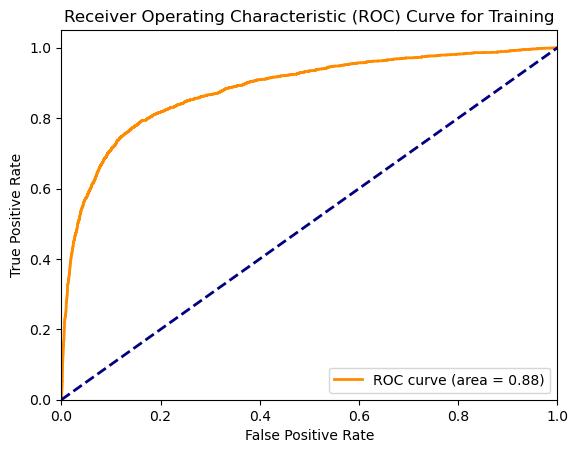

AUROC for Validation: 0.88


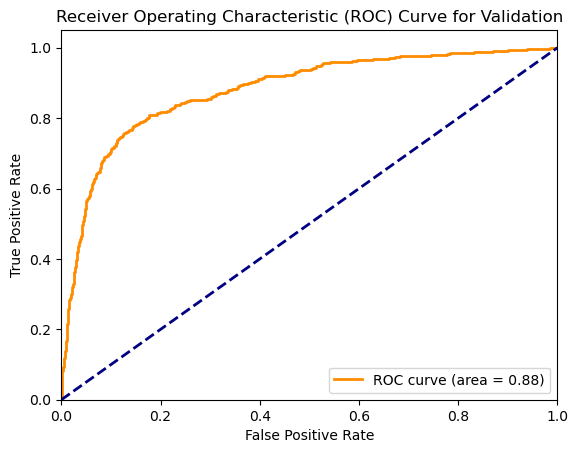

In [122]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

In [128]:
from sklearn.metrics import f1_score
f1_score(train_targets, train_preds, pos_label=1)

0.6352429296591733

In [130]:
f1_score(val_targets, val_preds, pos_label=1)

0.641192917054986

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [132]:
def all_no(inputs):
    return np.full(len(inputs), 0)

In [142]:
from sklearn.metrics import accuracy_score
print("Predicted train accuracy:", accuracy_score(train_targets, train_preds))
print("Predicted validaty accuracy:", accuracy_score(val_targets, val_preds))
print("Always no train accuracy:", accuracy_score(train_targets, all_no(X_train)))
print("Always no validaty accuracy:", accuracy_score(val_targets, all_no(X_val)))

Predicted train accuracy: 0.87425
Predicted validaty accuracy: 0.8716666666666667
Always no train accuracy: 0.7965
Always no validaty accuracy: 0.7966666666666666


Наша модель значно краще передбачає ніж просто завжди передбачати мажоритарний клас. Але є над чим працювати, може бути ще краща

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [82]:
import joblib

bank_loyalty = {
    'model': model,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

joblib.dump(bank_loyalty, 'bank_loyalty.joblib')

model2 = joblib.load('bank_loyalty.joblib')

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [84]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [86]:
predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, bank_df[:5])

array([0.00654092, 0.0366679 , 0.37111937, 0.37653484, 0.97577854])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [89]:
test_raw_df = pd.read_csv('test.csv')
test_raw_df['Exited'] = predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, test_raw_df)
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Exited
0,15000,15594796.0,Chu,0.365155,Germany,Male,0.214286,0.2,0.696265,0.000000,1.0,1.0,0.789477,0.0,1.0,0.0,0.0,1.0,0.075316
1,15001,15642821.0,Mazzi,0.286396,France,Male,0.375000,0.5,0.000000,0.333333,1.0,1.0,0.337131,1.0,0.0,0.0,0.0,1.0,0.035366
2,15002,15716284.0,Onyekachi,0.656325,France,Male,0.446429,0.8,0.000000,0.333333,1.0,0.0,0.783859,1.0,0.0,0.0,0.0,1.0,0.153210
3,15003,15785078.0,Martin,0.682578,Spain,Male,0.482143,0.3,0.000000,0.000000,1.0,1.0,0.834571,0.0,0.0,1.0,0.0,1.0,0.194872
4,15004,15662955.0,Kenechukwu,0.384248,Spain,Male,0.446429,0.8,0.000000,0.333333,1.0,1.0,0.718421,0.0,0.0,1.0,0.0,1.0,0.055660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,0.496420,Spain,Male,0.357143,1.0,0.000000,0.333333,1.0,1.0,0.248154,0.0,0.0,1.0,0.0,1.0,0.022145
9996,24996,15739271.0,Clements,0.589499,Spain,Male,0.375000,0.9,0.000000,0.333333,1.0,1.0,0.712578,0.0,0.0,1.0,0.0,1.0,0.026017
9997,24997,15756743.0,Chidiebere,0.818616,France,Male,0.214286,0.9,0.000000,0.333333,1.0,0.0,0.024253,1.0,0.0,0.0,0.0,1.0,0.018623
9998,24998,15680167.0,Yermakova,0.391408,France,Male,0.357143,0.6,0.690650,0.000000,1.0,0.0,0.632348,1.0,0.0,0.0,0.0,1.0,0.155567


12. Зчитайте файл 'sample_submission.csv' і заповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [91]:
submission = pd.read_csv('sample_submission.csv')
submission['Exited'] = test_raw_df['id'].map(test_raw_df.set_index('id')['Exited'])
submission.to_csv('submission_log_reg.csv', index=False)